In [14]:
# Load libraries
import os, sys
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib

from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
import warnings

%matplotlib inline
# plt.rcParams["figure.figsize"] = (12, 6)
# plt.rcParams['figure.dpi'] = 100

warnings.filterwarnings("ignore")

In [15]:
data_path  = "Data/pima-indians-diabetes.csv"
data_names = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin","BMI","DiabetesPedigreeFunction","Age","Outcome"]
df = pd.read_csv(data_path, names = data_names)

In [16]:
# shape
print(f'+ Shape: {df.shape}')
# head, tail
print(f'+ Contents: ')
display.display(df.head(5))
display.display(df.tail(5))

+ Shape: (768, 9)
+ Contents: 


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


**Nhận xét**:
+ Dữ liệu có 9 tính chất để phân lớp: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome
+ Giá trị Outcome xác định dương tính với bệnh tiểu đường
+ Tổng số dòng dữ liệu là 768 dòng
+ Dữ liệu để phân lớp ở cột class

#### (2) **Kiểm tra tính toàn vẹn của dữ liệu**
+ Dữ liệu có bị trùng lặp không? Hiển thị dòng bị vi phạm.
+ Dữ liệu có tồn tại giá trị Null\NaN không? Hiển thị dòng bị vi phạm.

In [17]:
# Rút gọn việc tính toán bằng cách kiểm tra trực tiếp
has_null = df.isnull().values.any()
n_duplicated = df.duplicated().sum()
print(f'Tính toàn vẹn dữ liệu:')
print(f'+ Có giá trị Null/Nan: {has_null}')
print(f'+ Số dòng trùng: {n_duplicated}')
# Hiển thị nhanh bằng toán học điều kiện (Short-circuit evaluation)
if has_null: display.display(df[df.isnull().any(axis=1)])
if n_duplicated > 0: display.display(df[df.duplicated(keep=False)])
#loai bỏ các dòng trùng
df = df.drop_duplicates()
print(f'+ Số dòng sau khi loại bỏ trùng: {df.shape[0]}')

Tính toàn vẹn dữ liệu:
+ Có giá trị Null/Nan: False
+ Số dòng trùng: 0
+ Số dòng sau khi loại bỏ trùng: 768


- Dữ liệu có quá bất hợp lý không: (ví dụ: Huyết áp quá thấp, BMI âm, tuổi vượt ngưỡng) (Nếu có hiển thị giá trị và số giá trị lỗi)
+ Pregnancies: 0–20
+ Glucose: 20–300
+ BloodPressure: 40–200
+ BMI: 10–80
+ Age: 21–100


In [18]:
physiological_ranges = {
    "Pregnancies": (0, 20),
    "Glucose": (20, 300),
    "BloodPressure": (40, 200),
    "BMI": (10, 80),
    "Age": (21, 100)
}

def detect_physiological_errors(df, ranges):
    errors = {}
    for col, (min_val, max_val) in ranges.items():
        if col not in df.columns:
            continue
        # lọc giá trị ngoài khoảng hợp lệ
        mask = (df[col] < min_val) | (df[col] > max_val)
        problem_series = df.loc[mask, col]
        errors[col] = {
            "count": problem_series.shape[0],
            "min_actual": df[col].min(),
            "max_actual": df[col].max(),
            "problem_values": sorted(problem_series.unique().tolist())
        }

    return errors
errors = detect_physiological_errors(df, physiological_ranges)

print("--- Dữ liệu lỗi phát hiện ---")
for col, info in errors.items():
    if info["count"] == 0:
        continue  # bỏ qua cột không có lỗi
    print(f"{col}: {info['count']} giá trị lỗi")
    print(f"    - Range thực tế: {info['min_actual']} - {info['max_actual']}")
    print(f"    - Giá trị có vấn đề: {info['problem_values']}")

--- Dữ liệu lỗi phát hiện ---
Glucose: 5 giá trị lỗi
    - Range thực tế: 0 - 199
    - Giá trị có vấn đề: [0]
BloodPressure: 39 giá trị lỗi
    - Range thực tế: 0 - 122
    - Giá trị có vấn đề: [0, 24, 30, 38]
BMI: 11 giá trị lỗi
    - Range thực tế: 0.0 - 67.1
    - Giá trị có vấn đề: [0.0]


In [19]:
rows_before = len(df)
df_clean = df.copy()

# ===== tạo mask tổng =====
invalid_mask_total = pd.Series(False, index=df_clean.index)

for col, (min_val, max_val) in physiological_ranges.items():
    if col in df_clean.columns:
        invalid_mask = (df_clean[col] < min_val) | (df_clean[col] > max_val)
        # cộng dồn mask
        invalid_mask_total |= invalid_mask
        # gán NaN
        df_clean.loc[invalid_mask, col] = np.nan

print("Đã đánh dấu NaN cho dữ liệu ngoài khoảng.")

Đã đánh dấu NaN cho dữ liệu ngoài khoảng.


In [20]:
# đếm số dòng có ít nhất 1 lỗi
rows_with_error = invalid_mask_total.sum()
# xóa các dòng có NaN ở các cột sinh lý
df_clean = df_clean.dropna(subset=physiological_ranges.keys())

rows_after = len(df_clean)

print("\n=== ĐỐI CHIẾU SỐ DÒNG ===")
print(f"Số dòng ban đầu: {rows_before}")
print(f"Số dòng có lỗi (unique rows): {rows_with_error}")
print(f"Số dòng sau khi làm sạch: {rows_after}")
print(f"Số dòng bị loại thực tế: {rows_before - rows_after}")

print(f"Tỷ lệ giữ lại: {rows_after / rows_before * 100:.1f}%")


=== ĐỐI CHIẾU SỐ DÒNG ===
Số dòng ban đầu: 768
Số dòng có lỗi (unique rows): 48
Số dòng sau khi làm sạch: 720
Số dòng bị loại thực tế: 48
Tỷ lệ giữ lại: 93.8%


In [21]:
def handle_zero_values(df):
    zero_sensitive_columns = ['Insulin', 'SkinThickness']

    for col in zero_sensitive_columns:
        if col not in df.columns:
            continue

        zero_mask = df[col] == 0
        if zero_mask.any():
            print(f"Phát hiện {zero_mask.sum()} giá trị 0 trong {col}")

            median_val = df.loc[df[col] > 0, col].median()

            df.loc[zero_mask, col] = median_val

            print(f"    -> Đã thay thế bằng median: {median_val:.2f}")

    return df
df_clean = handle_zero_values(df_clean)


Phát hiện 332 giá trị 0 trong Insulin
    -> Đã thay thế bằng median: 126.00
Phát hiện 192 giá trị 0 trong SkinThickness
    -> Đã thay thế bằng median: 29.00


In [22]:
df = df_clean.copy()
print("\nDataset sau làm sạch:", df.shape)
display.display(df.tail(10))


Dataset sau làm sạch: (720, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
758,1.0,106.0,76.0,29,126,37.5,0.197,26.0,0
759,6.0,190.0,92.0,29,126,35.5,0.278,66.0,1
760,2.0,88.0,58.0,26,16,28.4,0.766,22.0,0
761,9.0,170.0,74.0,31,126,44.0,0.403,43.0,1
762,9.0,89.0,62.0,29,126,22.5,0.142,33.0,0
763,10.0,101.0,76.0,48,180,32.9,0.171,63.0,0
764,2.0,122.0,70.0,27,126,36.8,0.340,27.0,0
765,5.0,121.0,72.0,23,112,26.2,0.245,30.0,0
766,1.0,126.0,60.0,29,126,30.1,0.349,47.0,1
767,1.0,93.0,70.0,31,126,30.4,0.315,23.0,0


#### (3) **Các tính chất thống kê trên dữ liệu số**
+ Count, Mean, Standard Deviation, Minimum Value
+ 25th Percentile, 50th Percentile (Median), 75th Percentile, Maximum Value

In [23]:
description = df.describe().T
display.display(description)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,720.0,3.881944,3.365324,0.000,1.000,3.000,6.0000,17.00
Glucose,720.0,122.019444,30.773020,44.000,100.000,117.000,142.0000,199.00
BloodPressure,720.0,72.633333,12.006442,40.000,64.000,72.000,80.0000,122.00
SkinThickness,720.0,29.133333,9.008048,7.000,25.000,29.000,33.0000,99.00
Insulin,720.0,142.609722,88.762935,14.000,120.000,126.000,132.0000,846.00
BMI,720.0,32.440278,6.833674,18.200,27.500,32.400,36.6000,67.10
DiabetesPedigreeFunction,720.0,0.475118,0.333035,0.078,0.245,0.378,0.6295,2.42
Age,720.0,33.388889,11.782634,21.000,24.000,29.000,41.0000,81.00
Outcome,720.0,0.344444,0.475517,0.000,0.000,0.000,1.0000,1.00


#### (4) **Tần số xuất hiện (Distribution) trên dữ liệu phân lớp (Outcome) và dữ liệu danh mục (Category)**

Đối với bài toán phân lớp (classification problem), chúng ta cần tính số lần xuất hiện của thuộc tính phân lớp. Điều này là cần thiết cho vấn đề mất cân bằng (highly imbalanced problems) giữa các lớp nhằm cần xử lý đặc biệt trong bước chuẩn bị dữ liệu.

In [24]:
df["Outcome"].value_counts()

Outcome
0    472
1    248
Name: count, dtype: int64

**Nhận xét**:
+ Dữ liệu cần phân loại 2 loại Người dương tính và người âm tính
+ Các lớp có sự phân biệt, biết rằng người âm tính nhiều hơn người dương tính

#### (5) **Mối tương quan giữa các tính chất (Correlations)**

Sự tương quan (correlation) đề cập đến mối quan hệ giữa hai biến và cách chúng có thể có hoặc không cùng nhau thay đổi.

Phương pháp phổ biến nhất để tính toán tương quan là Pearson's Correlation Coeficient, giả định có một phân phối chuẩn của các thuộc tính liên quan. Tương quan -1 hoặc 1 cho thấy mối tương quan âm hoặc dương đầy đủ tương ứng. Trong khi giá trị 0 hiển thị không tương quan ở tất cả. 

$$
r = \frac{\sum_{i=1}^n{\left(x_i - \hat{x}\right)\left(y_i - \hat{y}\right)}}{\sqrt{\sum_{i=1}^n{\left(x_i - \hat{x}\right)^2}\sum_{i=1}^n{\left(y_i - \hat{y}\right)^2}}}
$$

Một số thuật toán học máy như hồi quy tuyến tính và logistic có hiệu suất kém nếu có các thuộc tính tương quan cao trong tập dữ liệu của bạn. 

Như vậy, thật sự cần thiết để xem xét tất cả các mối tương quan theo cặp của các thuộc tính trong tập dữ liệu.

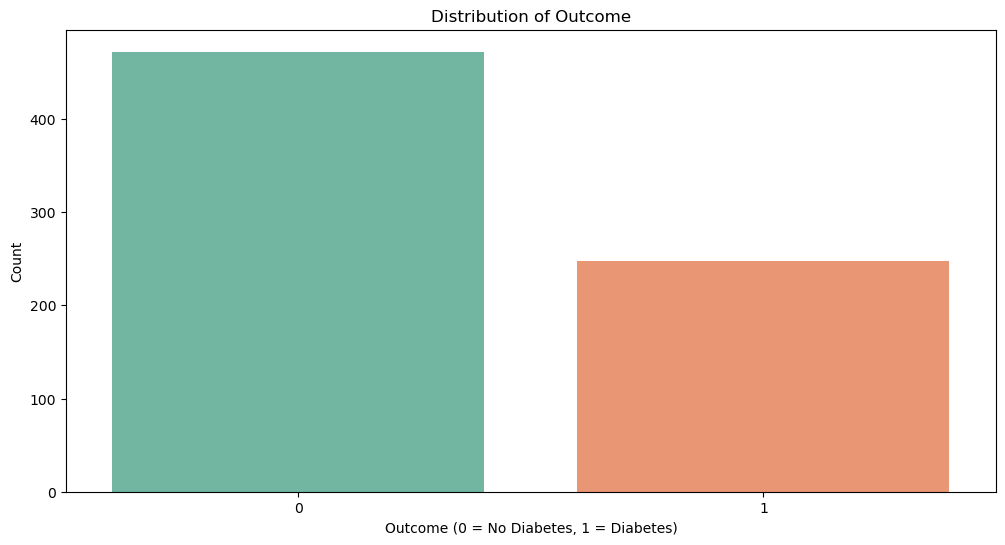

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x="Outcome", data=df, palette="Set2")
plt.title("Distribution of Outcome")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Count")
plt.show()

In [27]:
correlations = df.corr(method='pearson')
display.display(correlations)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.131649,0.200603,0.079248,0.020635,0.015871,-0.026973,0.556157,0.224474
Glucose,0.131649,1.000000,0.215218,0.197161,0.425416,0.230772,0.136593,0.261525,0.490550
BloodPressure,0.200603,0.215218,1.000000,0.199493,0.033782,0.315167,-0.003481,0.324737,0.169047
SkinThickness,0.079248,0.197161,0.199493,1.000000,0.154489,0.551256,0.108284,0.123499,0.213627
Insulin,0.020635,0.425416,0.033782,0.154489,1.000000,0.188231,0.129035,0.095278,0.211475
BMI,0.015871,0.230772,0.315167,0.551256,0.188231,1.000000,0.158135,0.021844,0.296571
DiabetesPedigreeFunction,-0.026973,0.136593,-0.003481,0.108284,0.129035,0.158135,1.000000,0.023350,0.184552
Age,0.556157,0.261525,0.324737,0.123499,0.095278,0.021844,0.023350,1.000000,0.246139
Outcome,0.224474,0.490550,0.169047,0.213627,0.211475,0.296571,0.184552,0.246139,1.000000
